# HELIX Revenue Prediction

## Notebook 03 — Categorical Analysis

Objective

Analyze categorical variables to understand
customer behavior and business characteristics.

In [ ]:
# import library
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

In [2]:
# load dataset
PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ecommerce_customer_behavior_dataset_v2.csv"

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

In [3]:
# categorical feature
target = "Total_Amount"

categorical_cols = [
    "Gender",
    "City",
    "Product_Category",
    "Payment_Method",
    "Device_Type",
    "Is_Returning_Customer",
]

categorical_cols

['Gender',
 'City',
 'Product_Category',
 'Payment_Method',
 'Device_Type',
 'Is_Returning_Customer']

In [4]:
# overview
summary = pd.DataFrame(
    {
        "Unique Values": df[categorical_cols].nunique(),
        "Missing": df[categorical_cols].isna().sum(),
    }
)

print(summary)

                       Unique Values  Missing
Gender                             3        0
City                              10        0
Product_Category                   8        0
Payment_Method                     5        0
Device_Type                        3        0
Is_Returning_Customer              2        0


Gender
Female    8613
Male      8176
Other      260
Name: count, dtype: int64


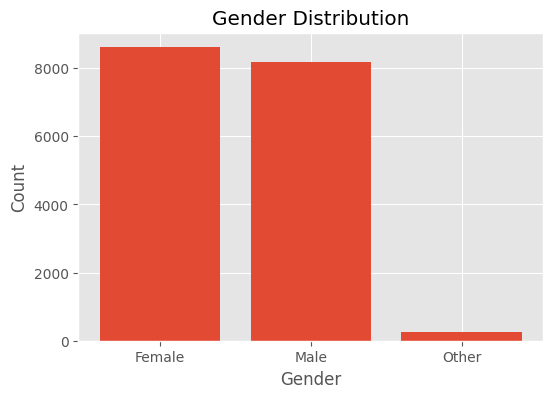

        count     mean  median          sum
Gender                                     
Female   8613  1281.55  463.94  11037984.60
Male     8176  1265.07  450.15  10343185.70
Other     260  1530.32  482.78    397882.29


In [6]:
# gender analysis
gender_count = df["Gender"].value_counts()

print(gender_count)

plt.figure(figsize=(6, 4))

plt.bar(gender_count.index, gender_count.values)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

# revenue berdasarkan gender
gender_revenue = (
    df.groupby("Gender")[target].agg(["count", "mean", "median", "sum"]).round(2)
)

print(gender_revenue)

City
Istanbul     4402
Ankara       2422
Izmir        2072
Bursa        1721
Adana        1326
Antalya      1246
Gaziantep    1183
Konya        1120
Kayseri       851
Eskisehir     706
Name: count, dtype: int64


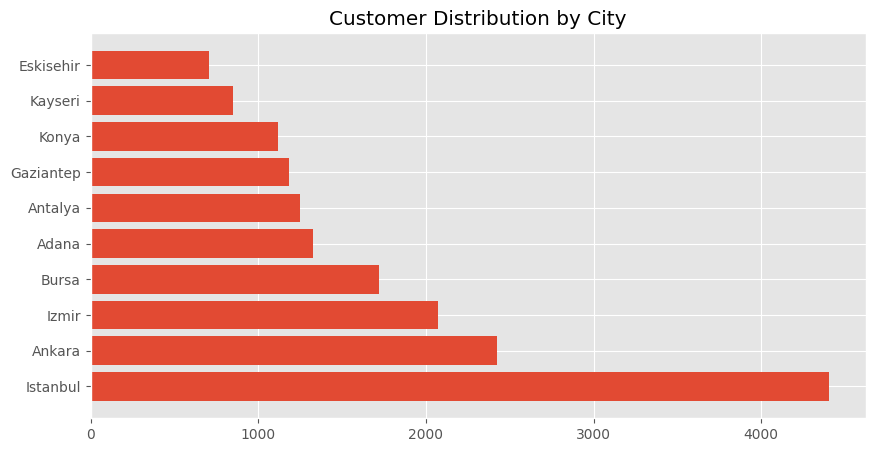

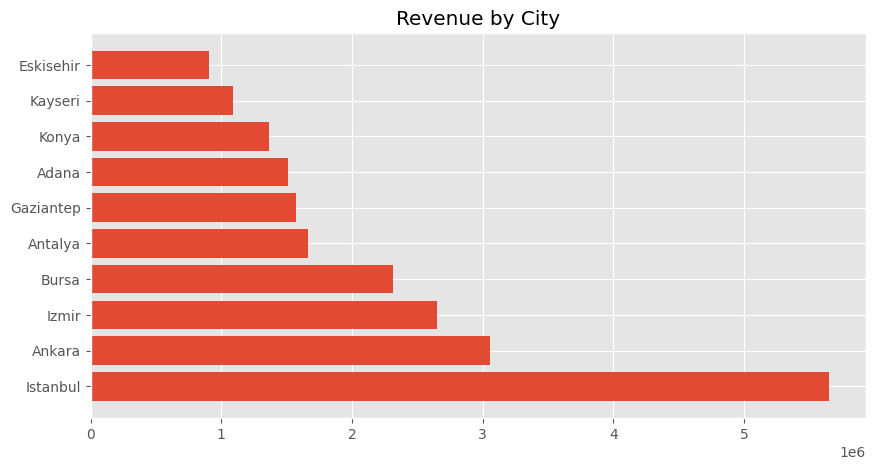

In [8]:
# city analysis
city_count = df["City"].value_counts()

print(city_count)

plt.figure(figsize=(10, 5))

plt.barh(city_count.index, city_count.values)

plt.title("Customer Distribution by City")

plt.show()

# revenue by city
city_revenue = df.groupby("City")[target].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

plt.barh(city_revenue.index, city_revenue.values)

plt.title("Revenue by City")

plt.show()

Product_Category
Sports           2248
Beauty           2212
Books            2206
Food             2103
Toys             2090
Electronics      2074
Home & Garden    2060
Fashion          2056
Name: count, dtype: int64


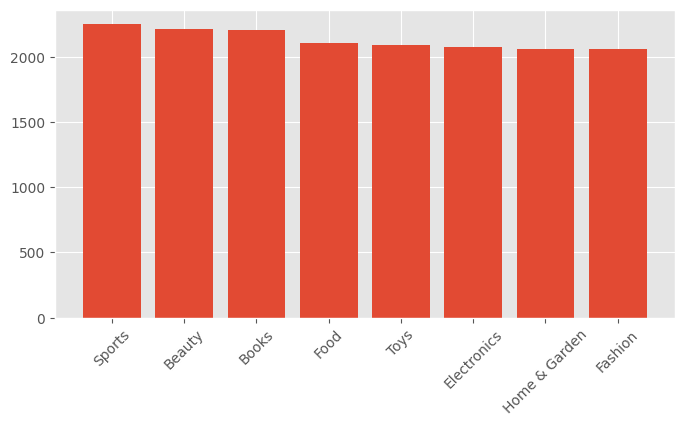

Product_Category
Electronics      10481897.65
Home & Garden     4023903.94
Sports            3205086.99
Fashion           1577035.70
Toys              1014237.53
Beauty             694437.02
Food               422054.65
Books              360399.11
Name: Total_Amount, dtype: float64


In [10]:
# product category
product_count = df["Product_Category"].value_counts()

print(product_count)

plt.figure(figsize=(8, 4))

plt.bar(product_count.index, product_count.values)

plt.xticks(rotation=45)

plt.show()

# product by revenue
product_revenue = (
    df.groupby("Product_Category")[target].sum().sort_values(ascending=False)
)

print(product_revenue)

Payment_Method
Credit Card         6801
Debit Card          4321
Digital Wallet      3276
Bank Transfer       1763
Cash on Delivery     888
Name: count, dtype: int64


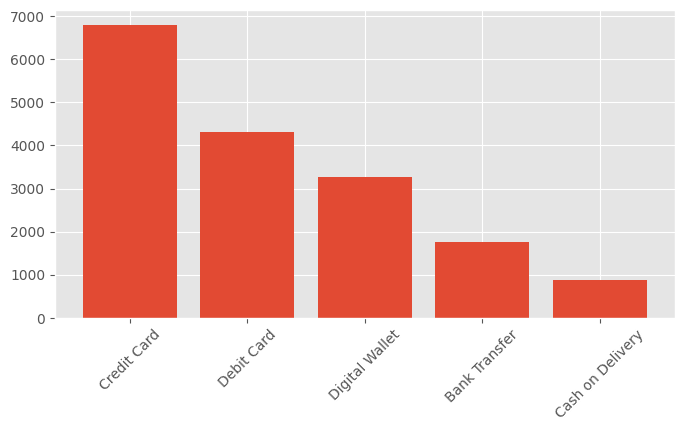

Payment_Method
Credit Card         9069714.65
Debit Card          5152182.83
Digital Wallet      4191842.00
Bank Transfer       2311499.25
Cash on Delivery    1053813.86
Name: Total_Amount, dtype: float64


In [12]:
# payment method
payment = df["Payment_Method"].value_counts()

print(payment)

plt.figure(figsize=(8, 4))

plt.bar(payment.index, payment.values)

plt.xticks(rotation=45)

plt.show()

# payment method by revenue
payment_revenue = (
    df.groupby("Payment_Method")[target].sum().sort_values(ascending=False)
)

print(payment_revenue)

Device_Type
Mobile     9543
Desktop    5845
Tablet     1661
Name: count, dtype: int64


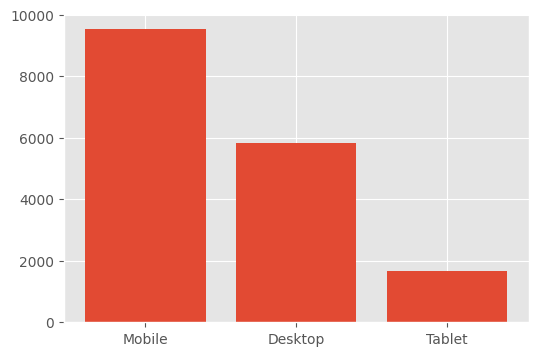

Device_Type
Desktop     7661437.07
Mobile     12028685.29
Tablet      2088930.23
Name: Total_Amount, dtype: float64


In [14]:
# device type
device = df["Device_Type"].value_counts()

print(device)

plt.figure(figsize=(6, 4))

plt.bar(device.index, device.values)

plt.show()

# revenue by device type
device_revenue = df.groupby("Device_Type")[target].sum()

print(device_revenue)

Is_Returning_Customer
True     15039
False     2010
Name: count, dtype: int64


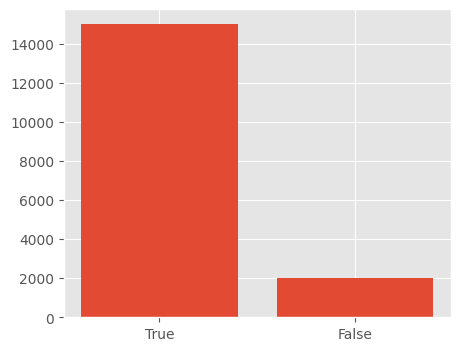

                       count         mean          sum
Is_Returning_Customer                                 
False                   2010  1287.727428   2588332.13
True                   15039  1276.063599  19190720.46


In [16]:
# returning customer
customer = df["Is_Returning_Customer"].value_counts()

print(customer)

plt.figure(figsize=(5, 4))

plt.bar(customer.index.astype(str), customer.values)

plt.show()

# revenue by returning customer
customer_revenue = df.groupby("Is_Returning_Customer")[target].agg(
    ["count", "mean", "sum"]
)

print(customer_revenue)

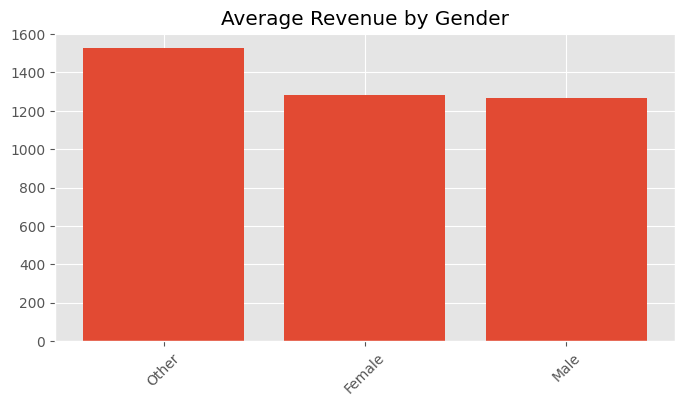

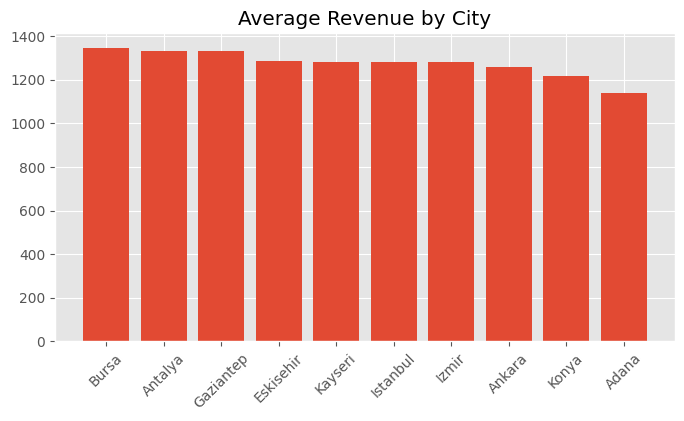

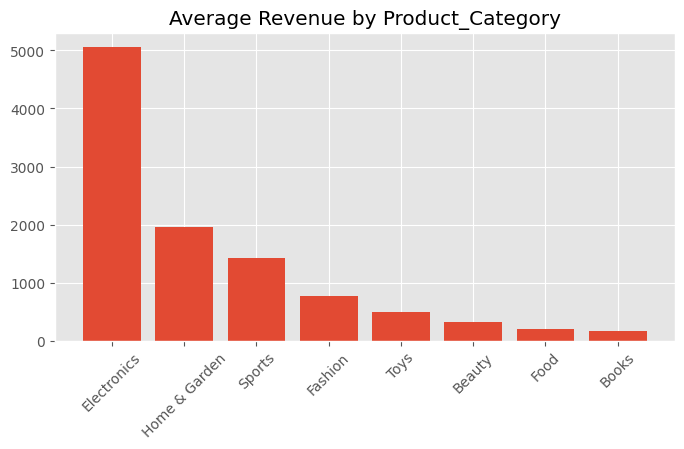

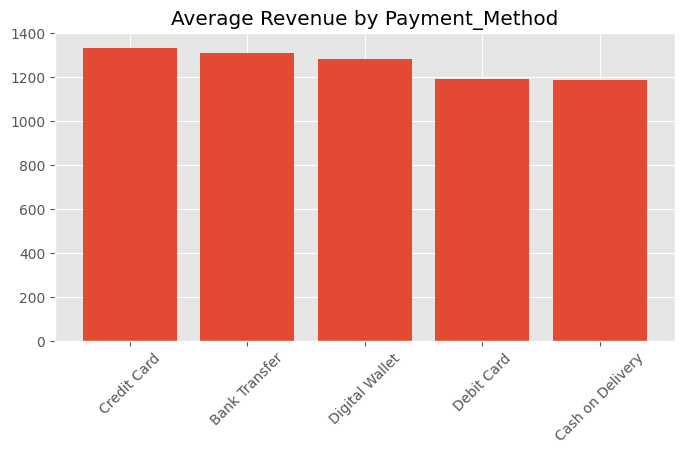

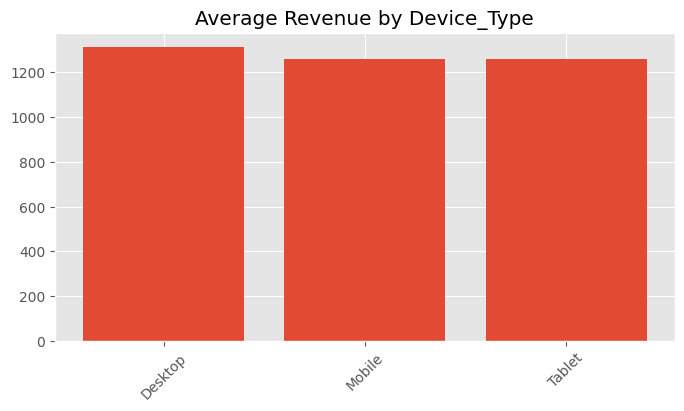

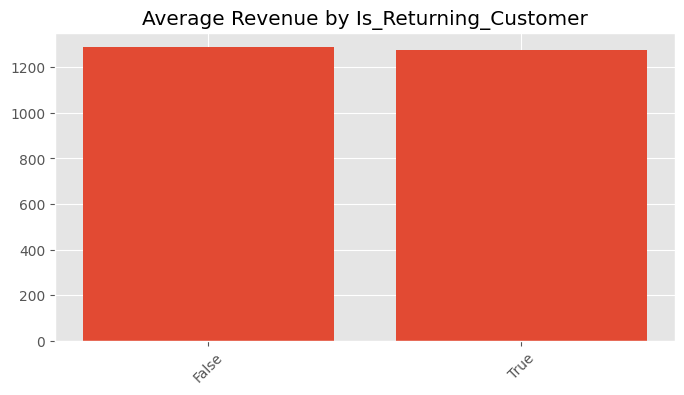

In [17]:
# revenue by category
for col in categorical_cols:
    revenue = df.groupby(col)[target].mean().sort_values(ascending=False)

    plt.figure(figsize=(8, 4))

    plt.bar(revenue.index.astype(str), revenue.values)

    plt.xticks(rotation=45)

    plt.title(f"Average Revenue by {col}")

    plt.show()

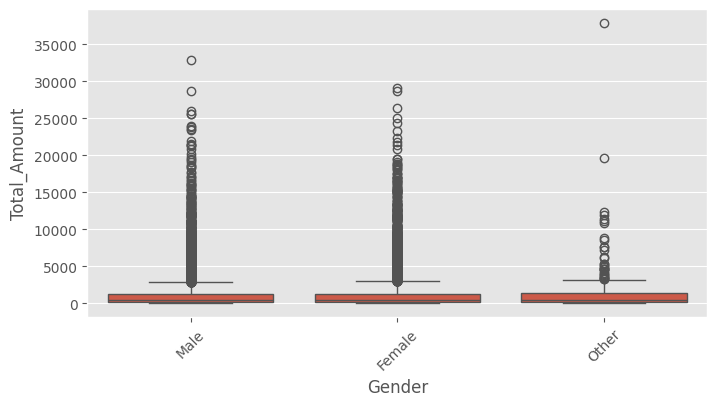

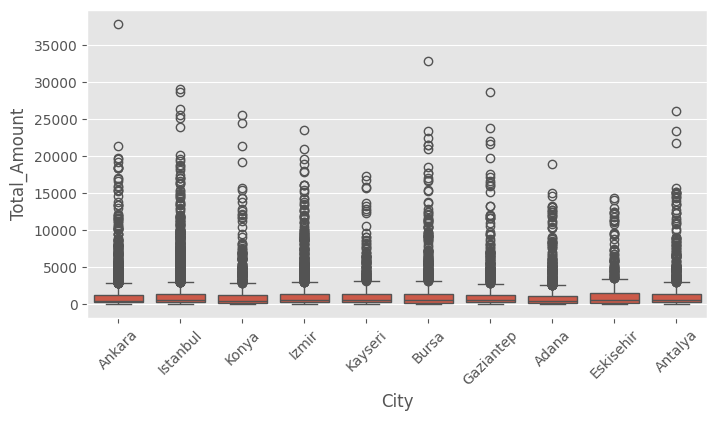

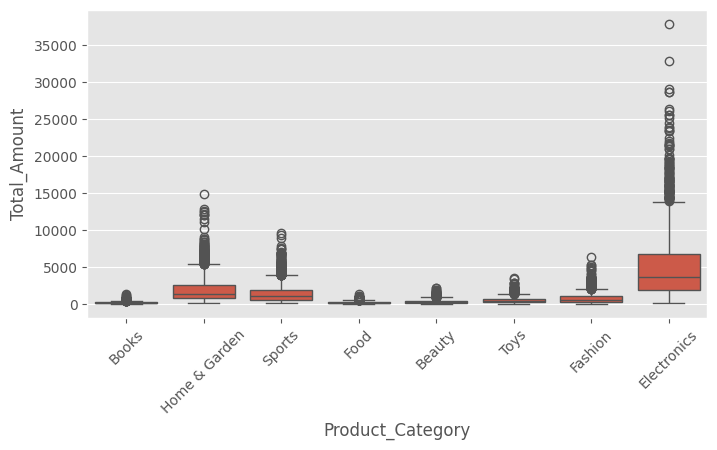

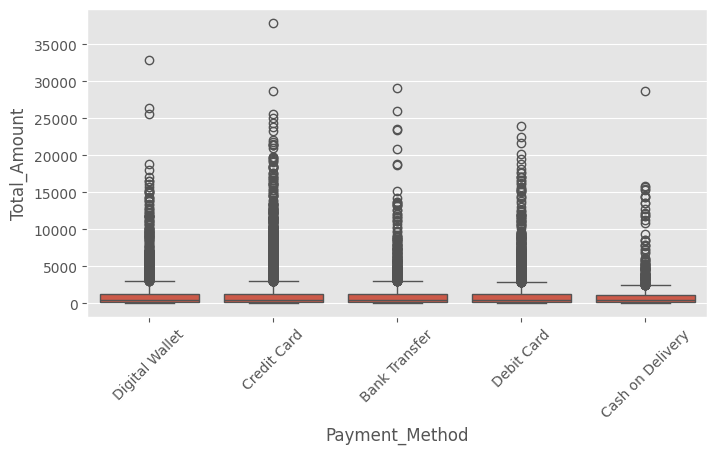

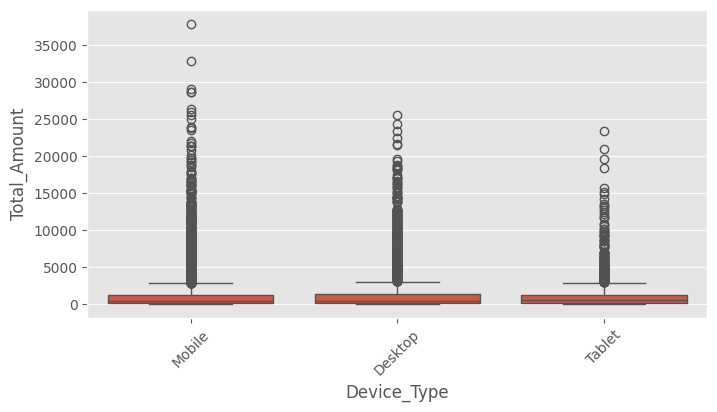

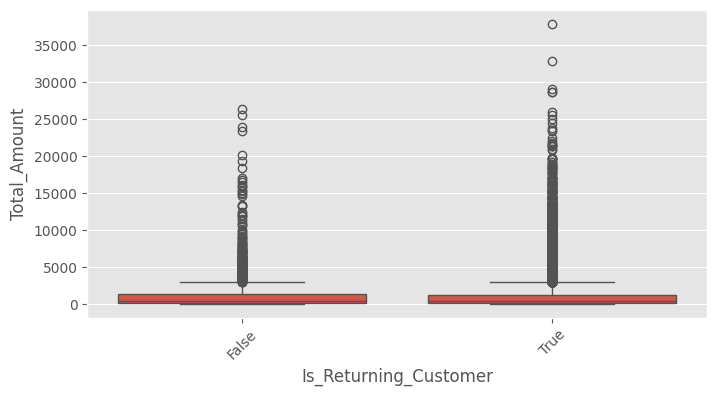

In [18]:
# revenue distribution
for col in categorical_cols:
    plt.figure(figsize=(8, 4))

    sns.boxplot(data=df, x=col, y=target)

    plt.xticks(rotation=45)

    plt.show()

In [19]:
# cardinality
cardinality = df[categorical_cols].nunique().sort_values(ascending=False)

print(cardinality)

City                     10
Product_Category          8
Payment_Method            5
Gender                    3
Device_Type               3
Is_Returning_Customer     2
dtype: int64


# Business Insights

## Gender

- Evaluate purchasing differences between male and female customers.

## City

- Identify cities contributing the highest revenue.
- Investigate underperforming regions.

## Product Category

- Determine top-performing product categories.

## Payment Method

- Understand customer payment preferences.

## Device Type

- Analyze customer shopping behavior across devices.

## Returning Customer

- Compare spending behavior between new and returning customers.

## Recommendation

### Low Cardinality

Use:

- One Hot Encoding

for:

- Gender
- Device_Type
- Payment_Method

---

### Medium Cardinality

Evaluate:

- Product_Category

---

### High Cardinality

Evaluate Frequency Encoding for:

- City

---

### Boolean

Convert:

True → 1

False → 0